# LLM Inference Performance Analysis

This notebook visualises results from `perf/load_test.py`.

| Metric | Description |
|--------|-------------|
| TTFT | Time-to-first-token (streaming) |
| TPOT | Time per output token |
| P50/P95/P99 | Tail-latency percentiles |
| GPU util | If nvidia-smi data available |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Dark theme
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#21262d',
    'figure.figsize': (14, 6), 'font.size': 11,
})
PAL = ['#58a6ff','#f78166','#7ee787','#d2a8ff','#ff7b72','#79c0ff','#ffa657']

BASE = Path('.')
df = pd.read_csv(BASE / 'metrics.csv')
agg = pd.read_csv(BASE / 'metrics_aggregate.csv') if (BASE / 'metrics_aggregate.csv').exists() else None
ok = df[df['latency_s'] > 0].copy()
print(f'Loaded {len(df)} rows ({len(ok)} ok, {len(df)-len(ok)} errors)')
ok.head()

Loaded 168 rows (168 ok, 0 errors)


,scenario,prompt_len,concurrency,stop_cfg,cached,run,req,ttft_s,latency_s,tokens,tok_per_s,finish,gpu_pct,gpu_mem_mb,gpu_total_mb
0,short_c1_none_miss,short,1,none,False,0,0,0.486215,0.561472,8,14.25,done,NaN,NaN,NaN
1,short_c1_none_miss,short,1,none,False,1,0,0.375316,0.624105,12,19.23,done,NaN,NaN,NaN
2,short_c1_none_hit,short,1,none,True,0,0,0.375798,0.518039,8,15.44,done,NaN,NaN,NaN
3,short_c1_none_hit,short,1,none,True,1,0,0.378828,0.528434,8,15.14,done,NaN,NaN,NaN
4,short_c1_period_miss,short,1,period,False,0,0,0.411091,0.510963,7,13.70,done,NaN,NaN,NaN


## 1 — Latency vs Concurrency

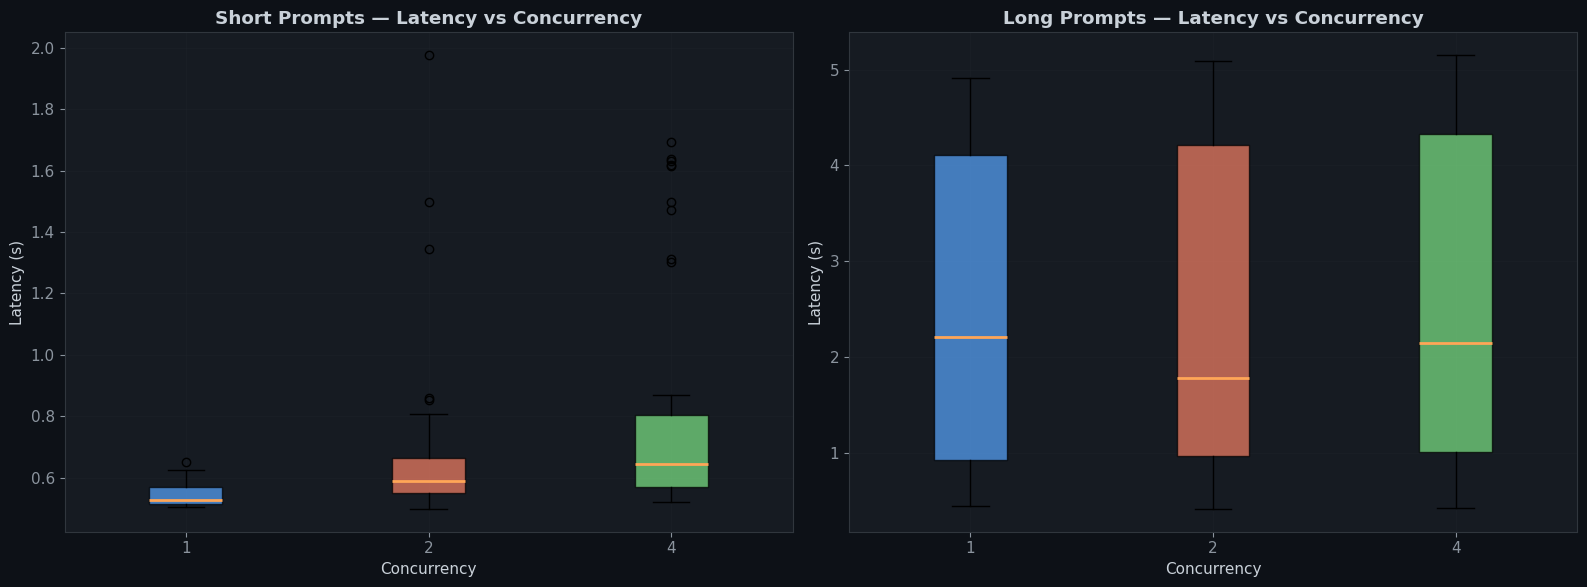

As concurrency rises, median latency grows due to GPU contention and scheduling overhead.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, ptype in enumerate(['short', 'long']):
    ax = axes[i]
    sub = ok[ok['prompt_len'] == ptype]
    levels = sorted(sub['concurrency'].unique())
    data = [sub[sub['concurrency']==c]['latency_s'].values for c in levels]
    bp = ax.boxplot(data, labels=[str(c) for c in levels], patch_artist=True,
                    medianprops={'color':'#ffa657','linewidth':2})
    for patch, col in zip(bp['boxes'], PAL): patch.set_facecolor(col); patch.set_alpha(0.7)
    ax.set_title(f'{ptype.title()} Prompts — Latency vs Concurrency', fontweight='bold')
    ax.set_xlabel('Concurrency'); ax.set_ylabel('Latency (s)'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(BASE/'plot_latency_concurrency.png', dpi=150, bbox_inches='tight'); plt.show()
print('As concurrency rises, median latency grows due to GPU contention and scheduling overhead.')

## 2 — P50 / P95 / P99 Percentile Bars

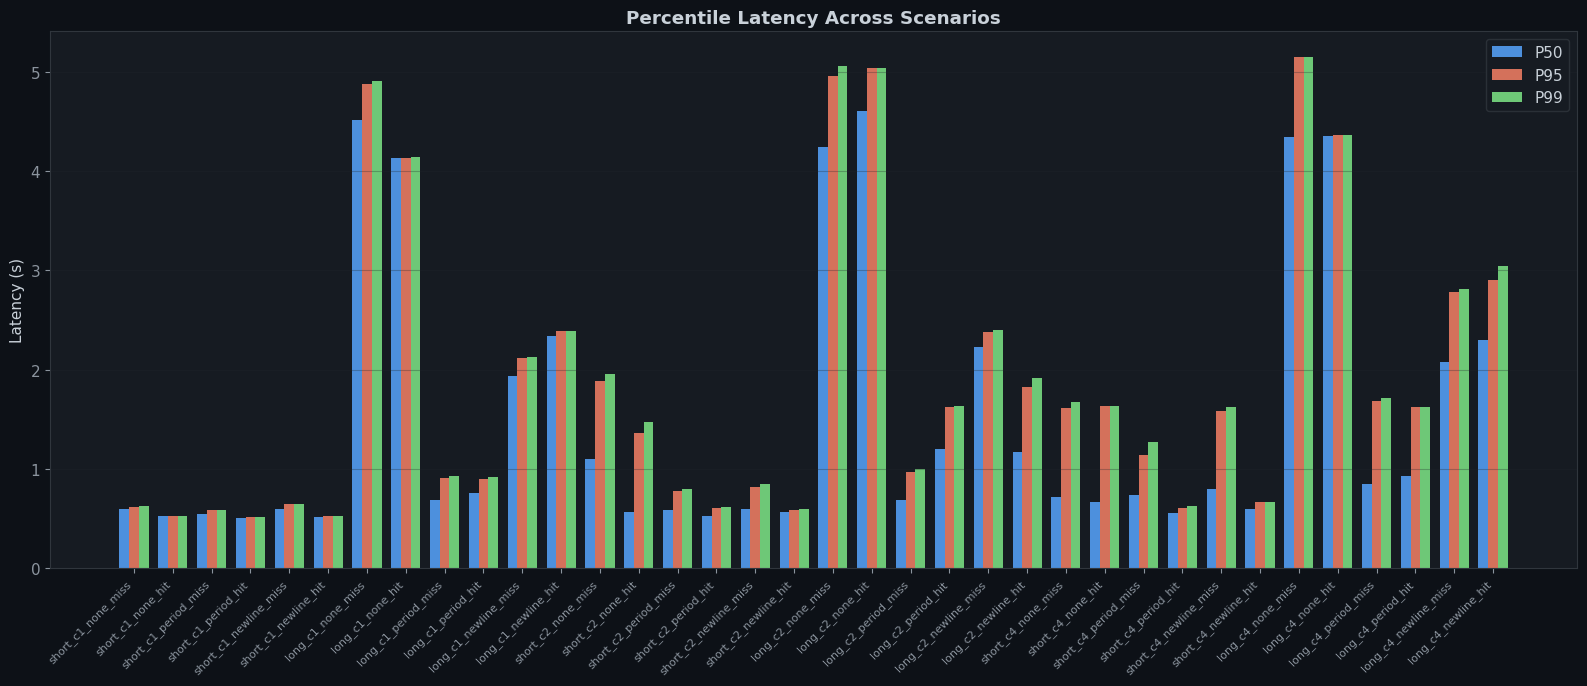

Large P50→P99 gaps indicate scheduling jitter or cold-start effects.


In [3]:
if agg is not None and len(agg):
    fig, ax = plt.subplots(figsize=(16, 7))
    x = np.arange(len(agg)); w = 0.25
    ax.bar(x-w, agg['p50'], w, label='P50', color=PAL[0], alpha=0.85)
    ax.bar(x,   agg['p95'], w, label='P95', color=PAL[1], alpha=0.85)
    ax.bar(x+w, agg['p99'], w, label='P99', color=PAL[2], alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(agg['scenario'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Latency (s)'); ax.set_title('Percentile Latency Across Scenarios', fontweight='bold')
    ax.legend(facecolor='#161b22', edgecolor='#30363d'); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout(); plt.savefig(BASE/'plot_percentiles.png', dpi=150, bbox_inches='tight'); plt.show()
    print('Large P50→P99 gaps indicate scheduling jitter or cold-start effects.')

## 3 — TTFT Distribution

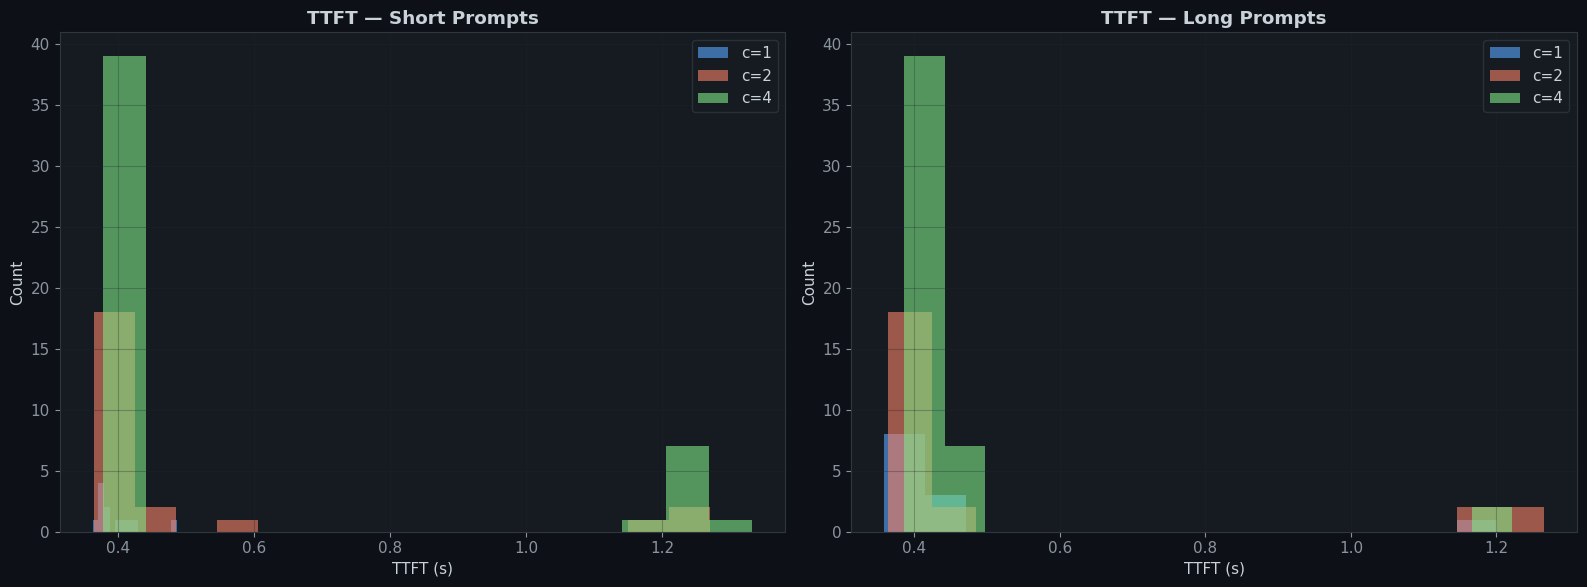

TTFT should stay stable across concurrency if vLLM continuous batching is effective.


In [4]:
ttft = ok.dropna(subset=['ttft_s'])
if len(ttft):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for i, pt in enumerate(['short','long']):
        ax = axes[i]; sub = ttft[ttft['prompt_len']==pt]
        for ci, c in enumerate(sorted(sub['concurrency'].unique())):
            ax.hist(sub[sub['concurrency']==c]['ttft_s'], bins=15, alpha=0.6,
                    label=f'c={c}', color=PAL[ci%len(PAL)])
        ax.set_title(f'TTFT — {pt.title()} Prompts', fontweight='bold')
        ax.set_xlabel('TTFT (s)'); ax.set_ylabel('Count')
        ax.legend(facecolor='#161b22', edgecolor='#30363d'); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(BASE/'plot_ttft.png', dpi=150, bbox_inches='tight'); plt.show()
    print('TTFT should stay stable across concurrency if vLLM continuous batching is effective.')

## 4 — Throughput (Tokens / sec)

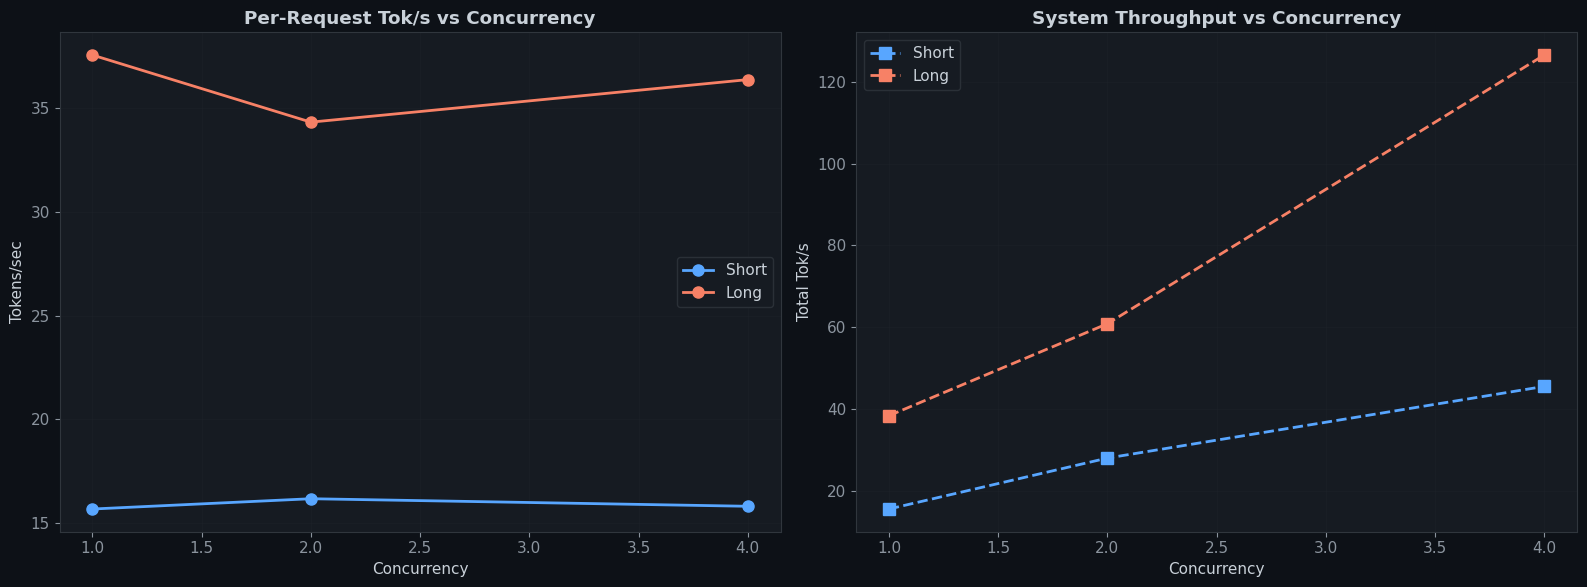

System throughput should scale with concurrency; per-request tok/s may drop slightly.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
for ci, pt in enumerate(['short','long']):
    g = ok[ok['prompt_len']==pt].groupby('concurrency')['tok_per_s'].mean()
    ax.plot(g.index, g.values, 'o-', color=PAL[ci], label=pt.title(), lw=2, ms=8)
ax.set_title('Per-Request Tok/s vs Concurrency', fontweight='bold')
ax.set_xlabel('Concurrency'); ax.set_ylabel('Tokens/sec')
ax.legend(facecolor='#161b22', edgecolor='#30363d'); ax.grid(True, alpha=0.3)

if agg is not None:
    ax = axes[1]
    for ci, pt in enumerate(['short','long']):
        g = agg[agg['prompt_len']==pt].groupby('concurrency')['sys_tok_s'].mean()
        ax.plot(g.index, g.values, 's--', color=PAL[ci], label=pt.title(), lw=2, ms=8)
    ax.set_title('System Throughput vs Concurrency', fontweight='bold')
    ax.set_xlabel('Concurrency'); ax.set_ylabel('Total Tok/s')
    ax.legend(facecolor='#161b22', edgecolor='#30363d'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(BASE/'plot_throughput.png', dpi=150, bbox_inches='tight'); plt.show()
print('System throughput should scale with concurrency; per-request tok/s may drop slightly.')

## 5 — Cache Hit vs Miss

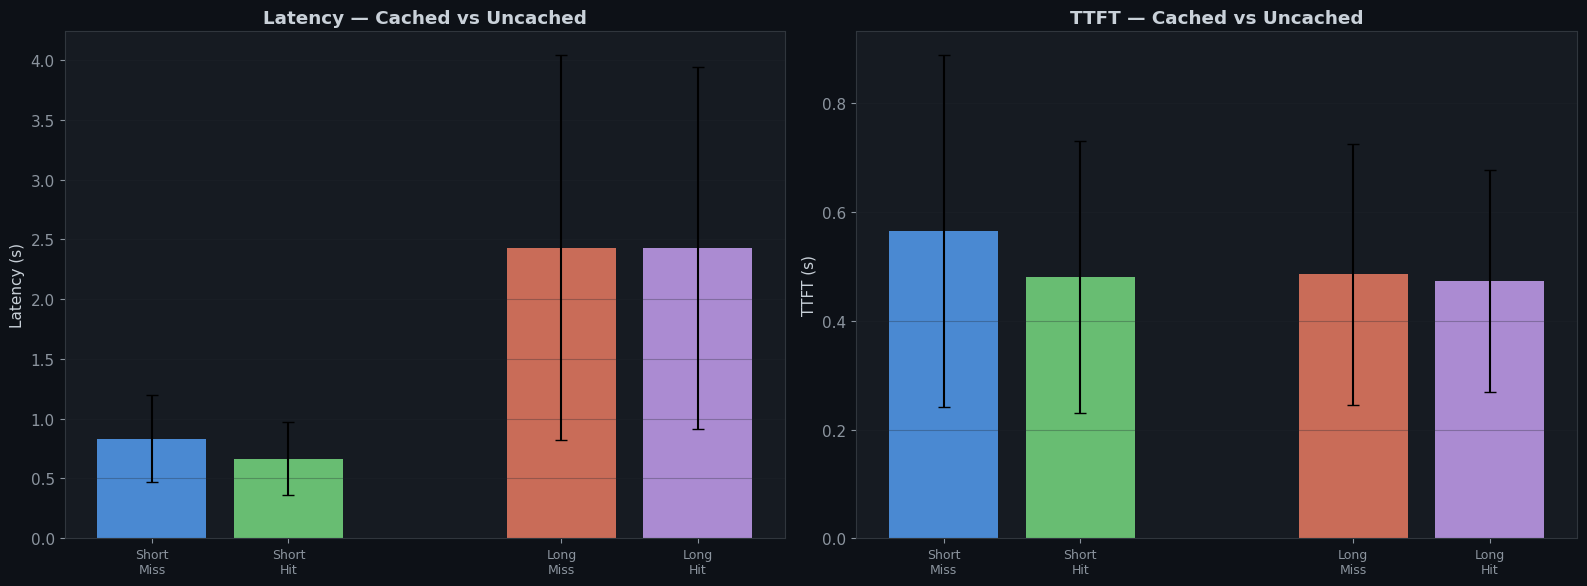

If prefix caching is enabled, repeated prompts should show lower TTFT.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for idx, col in enumerate(['latency_s', 'ttft_s']):
    ax = axes[idx]; title = 'Latency' if col == 'latency_s' else 'TTFT'
    subset = ok.dropna(subset=[col]) if col == 'ttft_s' else ok
    for ci, pt in enumerate(['short','long']):
        s = subset[subset['prompt_len']==pt]
        miss = s[s['cached']==False][col].values; hit = s[s['cached']==True][col].values
        pos = [ci*3, ci*3+1]
        means = [np.mean(miss) if len(miss) else 0, np.mean(hit) if len(hit) else 0]
        stds  = [np.std(miss) if len(miss) else 0, np.std(hit) if len(hit) else 0]
        ax.bar(pos, means, yerr=stds, width=0.8, color=[PAL[ci],PAL[ci+2]],
               alpha=0.8, capsize=4, error_kw={'color':'#8b949e'})
    ax.set_title(f'{title} — Cached vs Uncached', fontweight='bold')
    ax.set_ylabel(f'{title} (s)')
    ax.set_xticks([0,1,3,4]); ax.set_xticklabels(['Short\nMiss','Short\nHit','Long\nMiss','Long\nHit'], fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(BASE/'plot_cache.png', dpi=150, bbox_inches='tight'); plt.show()
print('If prefix caching is enabled, repeated prompts should show lower TTFT.')

## 6 — Stop Sequence Impact

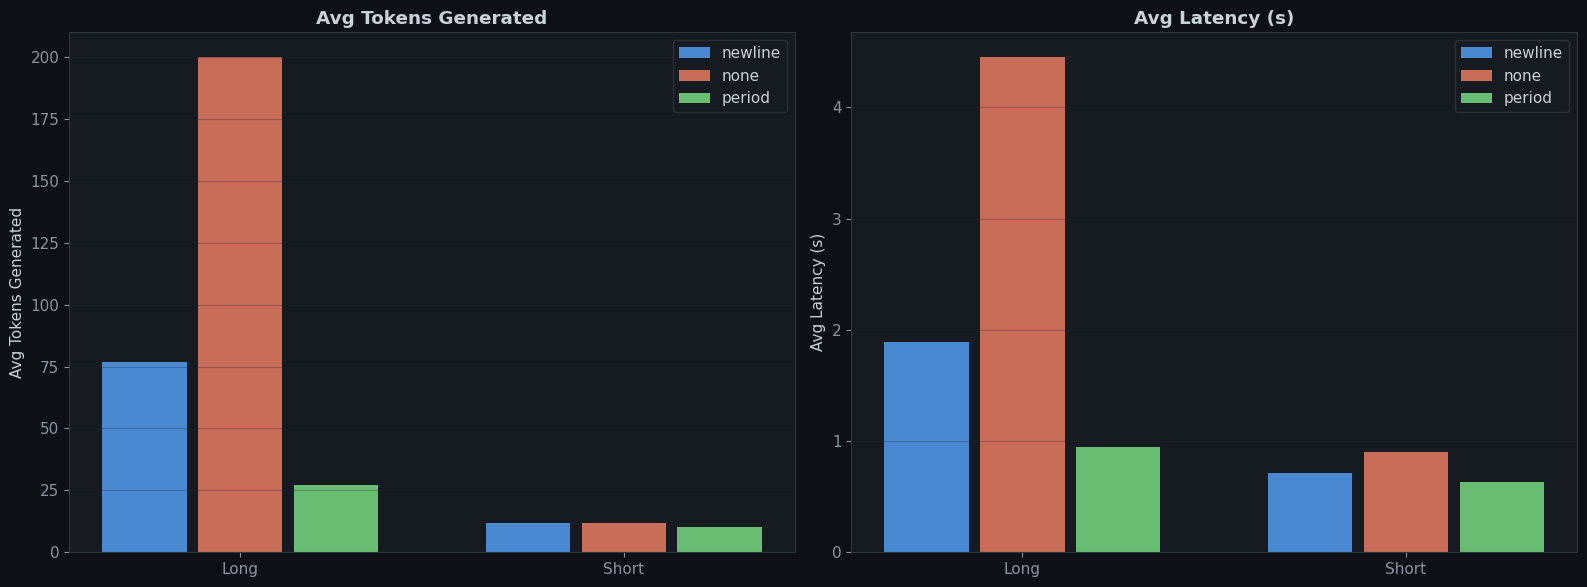

Strict stop sequences truncate early → fewer tokens, lower latency.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
scs = sorted(ok['stop_cfg'].unique())
for idx, (metric, label) in enumerate([('tokens','Avg Tokens Generated'),('latency_s','Avg Latency (s)')]):
    ax = axes[idx]
    for ci, sc in enumerate(scs):
        g = ok[ok['stop_cfg']==sc].groupby('prompt_len')[metric].mean()
        ax.bar([i+ci*0.25 for i in range(len(g))], g.values, width=0.22,
               label=sc, color=PAL[ci], alpha=0.8)
    ax.set_title(label, fontweight='bold'); ax.set_ylabel(label)
    ax.set_xticks([0.25,1.25]); ax.set_xticklabels(['Long','Short'])
    ax.legend(facecolor='#161b22', edgecolor='#30363d'); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(BASE/'plot_stop.png', dpi=150, bbox_inches='tight'); plt.show()
print('Strict stop sequences truncate early → fewer tokens, lower latency.')

## 7 — GPU Utilisation

In [8]:
gpu = ok.dropna(subset=['gpu_pct'])
if len(gpu):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    g = gpu.groupby('concurrency')['gpu_pct'].mean()
    axes[0].bar(g.index.astype(str), g.values, color=PAL[3], alpha=0.8)
    axes[0].set_title('GPU Util vs Concurrency', fontweight='bold')
    axes[0].set_ylabel('GPU %'); axes[0].set_ylim(0,105); axes[0].grid(True, alpha=0.3, axis='y')
    mem = gpu.dropna(subset=['gpu_mem_mb','gpu_total_mb'])
    if len(mem):
        u = mem.groupby('concurrency')['gpu_mem_mb'].mean()
        t = mem.groupby('concurrency')['gpu_total_mb'].mean()
        x = np.arange(len(u))
        axes[1].bar(x, t.values, 0.5, label='Total', color=PAL[4], alpha=0.4)
        axes[1].bar(x, u.values, 0.5, label='Used', color=PAL[4], alpha=0.8)
        axes[1].set_xticks(x); axes[1].set_xticklabels(u.index.astype(str))
        axes[1].set_title('GPU Memory', fontweight='bold'); axes[1].set_ylabel('MB')
        axes[1].legend(facecolor='#161b22', edgecolor='#30363d'); axes[1].grid(True, alpha=0.3, axis='y')
    plt.tight_layout(); plt.savefig(BASE/'plot_gpu.png', dpi=150, bbox_inches='tight'); plt.show()
else:
    print('No GPU data (nvidia-smi unavailable or remote endpoint).')

No GPU data (nvidia-smi unavailable or remote endpoint).


## 8 — Latency Heatmap

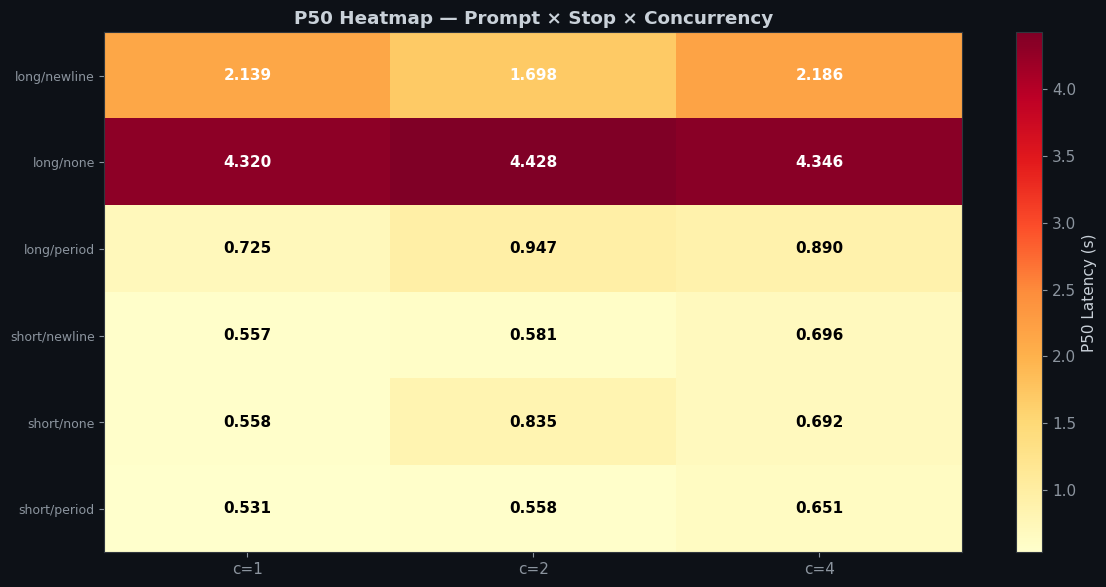

In [9]:
if agg is not None and len(agg):
    piv = agg.pivot_table(index=['prompt_len','stop_cfg'], columns='concurrency', values='p50', aggfunc='mean')
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(piv.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels([f'c={c}' for c in piv.columns])
    ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels([f'{a}/{b}' for a,b in piv.index], fontsize=9)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i,j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                        color='black' if v < np.nanmean(piv.values) else 'white', fontweight='bold')
    cb = plt.colorbar(im, ax=ax, label='P50 Latency (s)')
    cb.ax.yaxis.label.set_color('#c9d1d9')
    ax.set_title('P50 Heatmap — Prompt × Stop × Concurrency', fontweight='bold')
    plt.tight_layout(); plt.savefig(BASE/'plot_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

## 9 — Summary & Recommendations

| Finding | Explanation |
|---------|-------------|
| **Concurrency scaling** | Latency rises with concurrency but system throughput (tok/s) improves via batching |
| **TTFT stability** | Should stay constant if vLLM continuous batching is working |
| **Stop sequences** | Aggressive stops reduce output length and latency |
| **Caching** | Same-prompt repetition benefits from prefix caching |
| **GPU utilisation** | Higher concurrency drives GPU util up; early plateau indicates a non-GPU bottleneck |

### Recommendations
- **Latency-sensitive**: concurrency 1-2 with streaming
- **Throughput-oriented**: concurrency 4-8 to saturate batching
- Enable prefix caching on the vLLM server
- Tune `max_tokens` carefully — over-provisioning wastes GPU cycles
- Monitor P99: large P50→P99 gap signals scheduling jitter

In [10]:
if agg is not None and len(agg):
    cols = ['scenario','n','p50','p95','p99','ttft_p50','avg_tok_s','sys_tok_s','req_s']
    display = agg[cols].copy()
    display.columns = ['Scenario','N','P50(s)','P95(s)','P99(s)','TTFT P50','Avg Tok/s','Sys Tok/s','Req/s']
    print(display.to_string(index=False))
else:
    print('Run load_test.py first.')

             Scenario  N  P50(s)  P95(s)  P99(s)  TTFT P50  Avg Tok/s  Sys Tok/s  Req/s
   short_c1_none_miss  2  0.5928  0.6210  0.6235    0.4308      16.74      16.70   1.67
    short_c1_none_hit  2  0.5232  0.5279  0.5283    0.3773      15.29      15.15   1.89
 short_c1_period_miss  2  0.5510  0.5871  0.5903    0.3928      16.16      16.21   1.80
  short_c1_period_hit  2  0.5106  0.5160  0.5164    0.4188      13.71      13.53   1.93
short_c1_newline_miss  2  0.5926  0.6469  0.6518    0.3934      16.70      16.73   1.67
 short_c1_newline_hit  2  0.5206  0.5293  0.5301    0.3671      15.38      15.18   1.90
    long_c1_none_miss  2  4.5107  4.8753  4.9077    0.7940      44.70      44.29   0.22
     long_c1_none_hit  2  4.1294  4.1366  4.1373    0.3977      48.44      48.37   0.24
  long_c1_period_miss  2  0.6908  0.9060  0.9251    0.4207      18.34      22.92   1.43
   long_c1_period_hit  2  0.7590  0.9033  0.9162    0.4053      26.63      27.46   1.31
 long_c1_newline_miss  2  1.9381